#EKF
Ресурсы:

https://github.com/Janudis/Extended-Kalman-Filter-GPS_IMU


https://borglab.github.io/gtsam/ekf-slam/


https://deepwiki.com/commaai/rednose/3.4-cython-wrapper

https://github.com/mez/extended_kalman_filter_python (самый подходящий пайплайн)

https://automaticaddison.com/extended-kalman-filter-ekf-with-python-code-example/ (теория)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
class EKF:
    def __init__(self):
        self.x = np.zeros(3)
        self.P = np.eye(3) * 0.1   # ковариационная матрица неопределённости
        self.Q = np.eye(3) * 0.05  # шум движения
        self.R = np.eye(3) * 0.3   # шум датчика

    def predict(self, u):
        self.x[0] += u[0] * np.cos(self.x[2])
        self.x[1] += u[1] * np.sin(self.x[2])
        '''
        добавить зависимость от угловой скорости
        '''
        self.x[2] += u[2]

        A = np.array([
            [1, 0, -u[0] * np.sin(self.x[2])],
            [0, 1,  u[1] * np.cos(self.x[2])],
            [0, 0, 1]
        ])

        self.P = A @ self.P @ A.T + self.Q

    def update(self, z):
        H = np.eye(3)

        y = z - self.x
        S = H @ self.P @ H.T + self.R

        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(3) - K @ H) @ self.P

In [11]:
def generate_synthetic_data(dt=0.1, total_time=20.0):
    N = int(total_time / dt)
    t = np.linspace(0, total_time, N)

    radius = 3.0
    angular_speed = 0.5

    true_x = radius * np.cos(angular_speed * t)
    true_y = radius * np.sin(angular_speed * t)
    true_theta = angular_speed * t + np.pi/2

    true_dx = np.diff(true_x, prepend=true_x[0])
    true_dy = np.diff(true_y, prepend=true_y[0])
    true_dtheta = np.diff(true_theta, prepend=true_theta[0])

    odom_noise_xy = 0.05
    odom_noise_theta = 0.03

    acc_error_x = 0    #накопление ошибки
    acc_error_y = 0
    acc_error_theta = 0

    odom_x = np.zeros(N)
    odom_y = np.zeros(N)
    odom_theta = np.zeros(N)

    for i in range(N):
        if i == 0:
            odom_x[i] = true_x[i]
            odom_y[i] = true_y[i]
            odom_theta[i] = true_theta[i]
        else:
            error_x = np.random.normal(0, odom_noise_xy * abs(true_dx[i]))
            error_y = np.random.normal(0, odom_noise_xy * abs(true_dy[i]))
            error_theta = np.random.normal(0, odom_noise_theta * abs(true_dtheta[i]))

            acc_error_x += error_x
            acc_error_y += error_y
            acc_error_theta += error_theta

            odom_x[i] = odom_x[i-1] + true_dx[i] + acc_error_x
            odom_y[i] = odom_y[i-1] + true_dy[i] + acc_error_y
            odom_theta[i] = odom_theta[i-1] + true_dtheta[i] + acc_error_theta

    gps_noise = 0.3
    gps_x = true_x + np.random.normal(0, gps_noise, N)
    gps_y = true_y + np.random.normal(0, gps_noise, N)
    gps_theta = true_theta + np.random.normal(0, 0.1, N)

    return {
        't': t,
        'true': (true_x, true_y, true_theta),
        'odom': (odom_x, odom_y, odom_theta),
        'gps': (gps_x, gps_y, gps_theta),
        'dt': dt
    }

def run_ekf(data):
    t = data['t']
    true_x, true_y, true_theta = data['true']
    odom_x, odom_y, odom_theta = data['odom']
    gps_x, gps_y, gps_theta = data['gps']
    dt = data['dt']

    N = len(t)
    ekf = EKF()

    ekf_x = np.zeros(N)
    ekf_y = np.zeros(N)
    ekf_theta = np.zeros(N)

    ekf_x[0] = gps_x[0]
    ekf_y[0] = gps_y[0]
    ekf_theta[0] = gps_theta[0]
    ekf.x = np.array([ekf_x[0], ekf_y[0], ekf_theta[0]])

    for i in range(1, N):
        u = np.array([
            odom_x[i] - odom_x[i-1],
            odom_y[i] - odom_y[i-1],
            odom_theta[i] - odom_theta[i-1]
        ])
        ekf.predict(u)

        z = np.array([gps_x[i], gps_y[i], gps_theta[i]])
        ekf.update(z)

        ekf_x[i] = ekf.x[0]
        ekf_y[i] = ekf.x[1]
        ekf_theta[i] = ekf.x[2]

    return ekf_x, ekf_y, ekf_theta

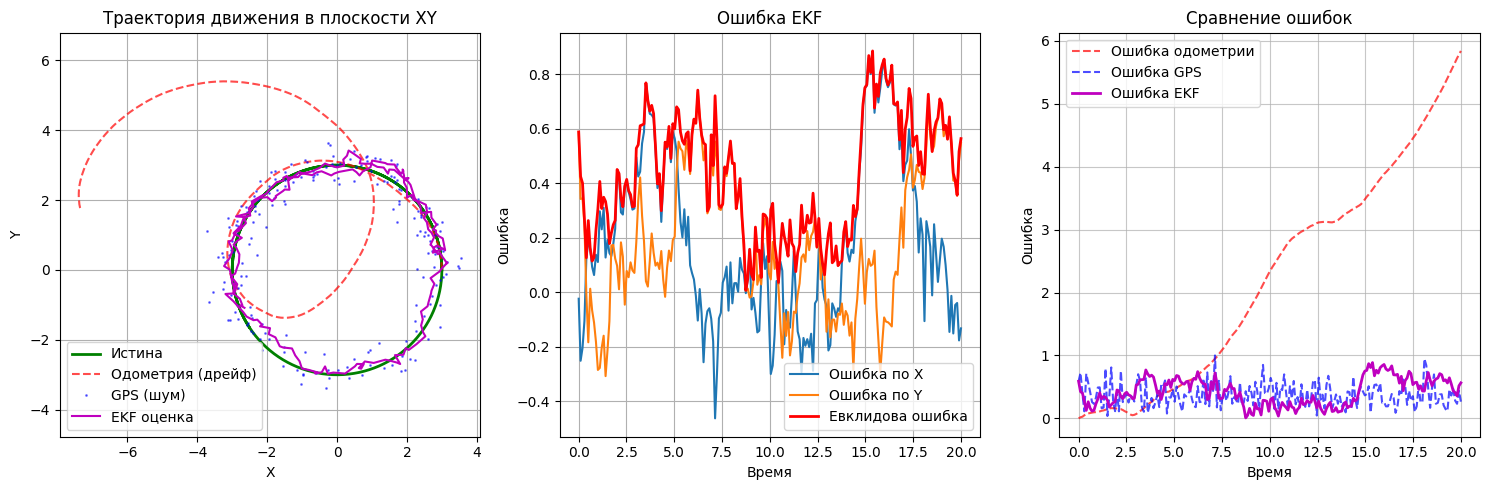

In [12]:
def plot_results(data, ekf_x, ekf_y):
    t = data['t']
    true_x, true_y, _ = data['true']
    odom_x, odom_y, _ = data['odom']
    gps_x, gps_y, _ = data['gps']

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(true_x, true_y, 'g-', linewidth=2, label='Истина')
    plt.plot(odom_x, odom_y, 'r--', alpha=0.7, label='Одометрия (дрейф)')
    plt.plot(gps_x, gps_y, 'b.', markersize=2, alpha=0.5, label='GPS (шум)')
    plt.plot(ekf_x, ekf_y, 'm-', linewidth=1.5, label='EKF оценка')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Траектория движения в плоскости XY')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')

    plt.subplot(1, 3, 2)
    error_x = ekf_x - true_x
    error_y = ekf_y - true_y
    error_dist = np.sqrt(error_x**2 + error_y**2)

    plt.plot(t, error_x, label='Ошибка по X')
    plt.plot(t, error_y, label='Ошибка по Y')
    plt.plot(t, error_dist, 'r-', linewidth=2, label='Евклидова ошибка')
    plt.xlabel('Время')
    plt.ylabel('Ошибка')
    plt.title('Ошибка EKF')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    odom_error = np.sqrt((odom_x - true_x)**2 + (odom_y - true_y)**2)
    gps_error = np.sqrt((gps_x - true_x)**2 + (gps_y - true_y)**2)

    plt.plot(t, odom_error, 'r--', label='Ошибка одометрии', alpha=0.7)
    plt.plot(t, gps_error, 'b--', label='Ошибка GPS', alpha=0.7)
    plt.plot(t, error_dist, 'm-', linewidth=2, label='Ошибка EKF')
    plt.xlabel('Время')
    plt.ylabel('Ошибка')
    plt.title('Сравнение ошибок')
    plt.legend()
    plt.grid(True, alpha=0.7)

    plt.tight_layout()
    plt.show()


data = generate_synthetic_data(dt=0.1, total_time=20.0)
ekf_x, ekf_y, ekf_theta = run_ekf(data)
plot_results(data, ekf_x, ekf_y)

Истинная траектория - робот едет по кругу

Посчитать среднюю ошибку